# Trabajo Práctico I - Visualización por Computadora I

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

---
## Parte 1: White Patch

In [2]:
# definimos el algoritmo de white patch
def white_patch(image):
    result = image.copy().astype(np.float64)
    for c in range(3):
        max_val = result[:, :, c].max()
        if max_val > 0:
            result[:, :, c] = result[:, :, c] * (255.0 / max_val)
    return np.clip(result, 0, 255).astype(np.uint8)

### Cargamos el primer set de imágenes

In [8]:
# hacemos carga de las imagenes a testear
wp_files = {
    'Roja (png)': 'tp_1/material/white_patch/wp_red.png',
    'Roja (jpg)': 'tp_1/material/white_patch/wp_red2.jpg',
    'Verde (png)': 'tp_1/material/white_patch/wp_green.png',
    'Verde (jpg)': 'tp_1/material/white_patch/wp_green2.jpg',
    'Azul (jpg)': 'tp_1/material/white_patch/wp_blue.jpg',
}

images = {}
for name, path in wp_files.items():
    img = cv.imread(path)
    if img is not None:
        images[name] = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        print(f'{name}: {img.shape}')
    else:
        print(f'ERROR: No se pudo cargar {path}')

Roja (png): (813, 481, 3)
Roja (jpg): (1600, 1200, 3)
Verde (png): (571, 363, 3)
Verde (jpg): (1600, 1200, 3)
Azul (jpg): (1600, 1200, 3)


### Aplicamos White Patch y comparamos resultados

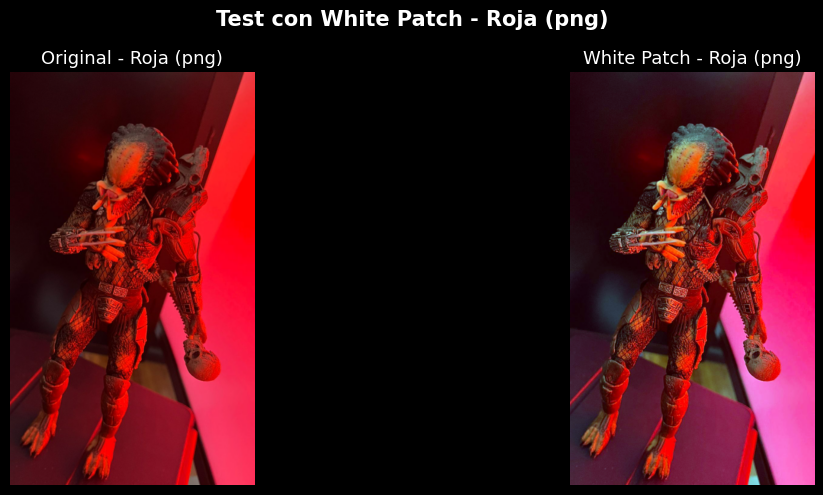

  Original  -> R max=255, G max=134, B max=122
  Corregida -> R max=255, G max=255, B max=255



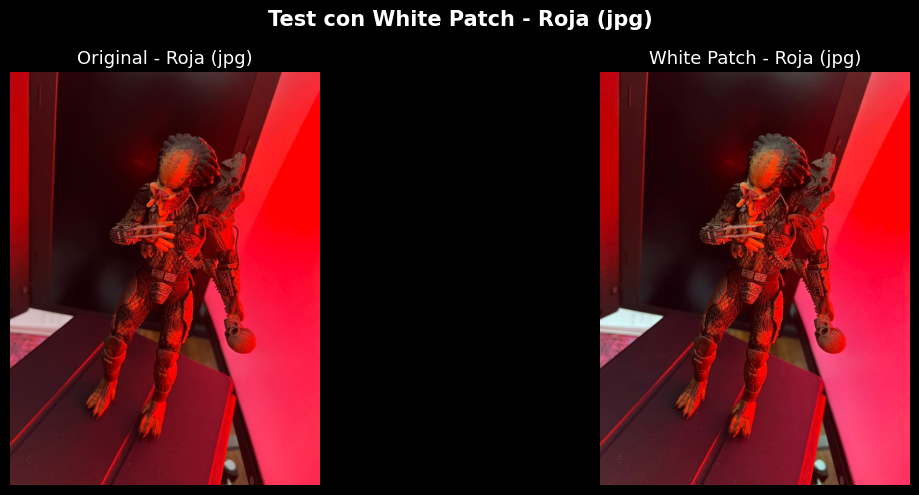

  Original  -> R max=255, G max=201, B max=203
  Corregida -> R max=255, G max=255, B max=254



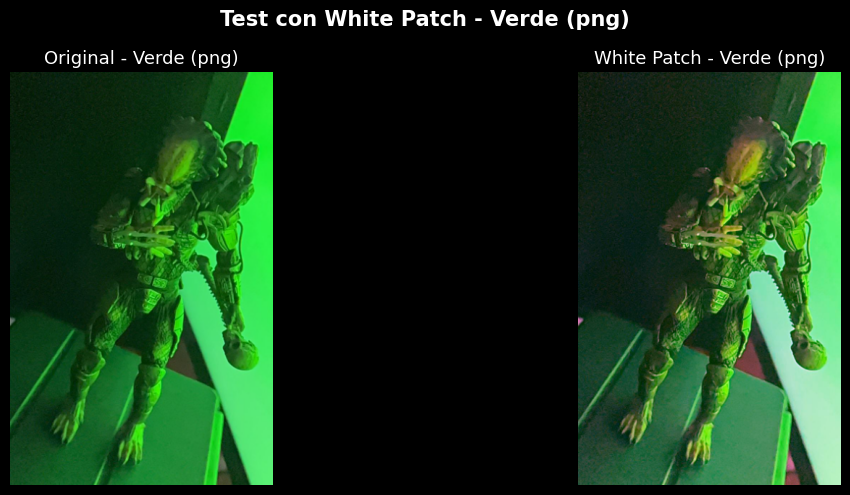

  Original  -> R max=126, G max=252, B max=155
  Corregida -> R max=255, G max=255, B max=255



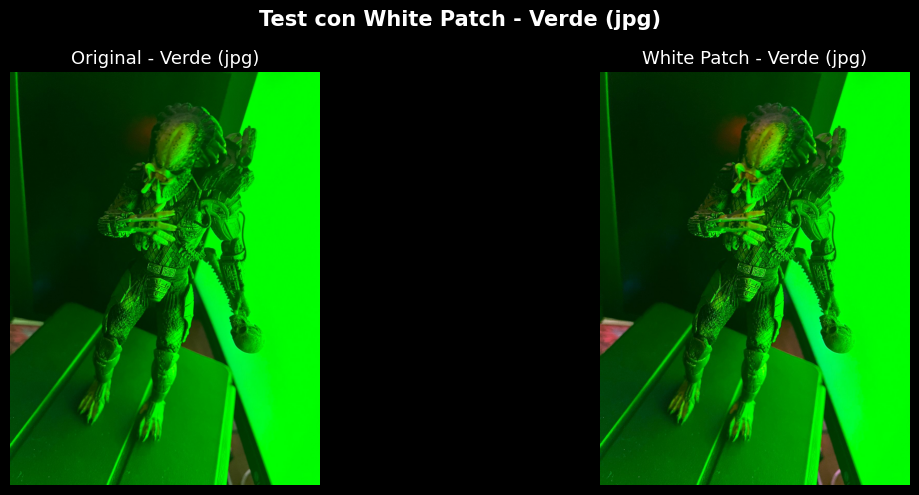

  Original  -> R max=170, G max=255, B max=172
  Corregida -> R max=255, G max=255, B max=255



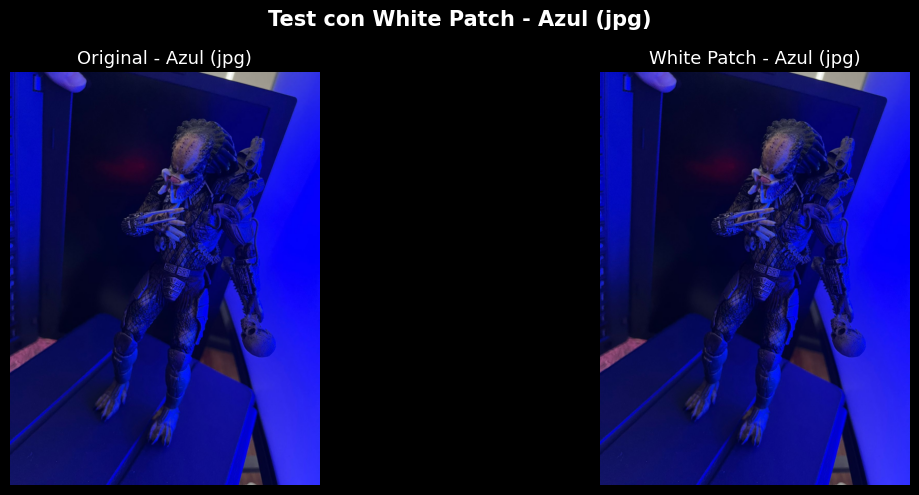

  Original  -> R max=255, G max=255, B max=255
  Corregida -> R max=255, G max=255, B max=255



In [15]:
for name, img in images.items():
    corrected = white_patch(img)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].imshow(img)
    axes[0].set_title(f'Original - {name}', fontsize=13)
    axes[0].axis('off')
    
    axes[1].imshow(corrected)
    axes[1].set_title(f'White Patch - {name}', fontsize=13)
    axes[1].axis('off')
    
    fig.suptitle(f'Test con White Patch - {name}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Mostrar estadísticas por canal
    print(f'  Original  -> R max={img[:,:,0].max()}, G max={img[:,:,1].max()}, B max={img[:,:,2].max()}')
    print(f'  Corregida -> R max={corrected[:,:,0].max()}, G max={corrected[:,:,1].max()}, B max={corrected[:,:,2].max()}')
    print()

### White Patch sobre imágenes de manos

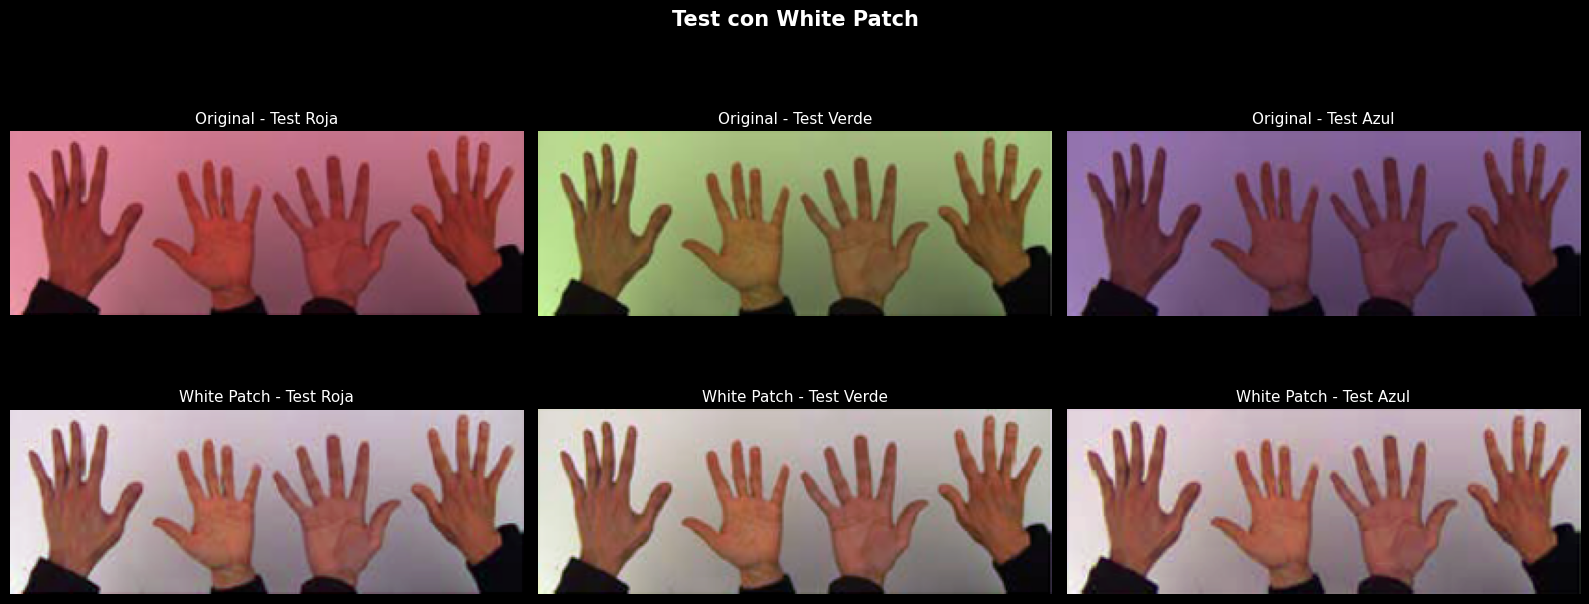

In [17]:
# Cargamos segundo set de imagenes
test_files = {
    'Test Roja': 'tp_1/material/white_patch/test_red.png',
    'Test Verde': 'tp_1/material/white_patch/test_green.png',
    'Test Azul': 'tp_1/material/white_patch/test_blue.png',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for idx, (name, path) in enumerate(test_files.items()):
    img = cv.cvtColor(cv.imread(path), cv.COLOR_BGR2RGB)
    corrected = white_patch(img)
    
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f'Original - {name}', fontsize=11)
    axes[0, idx].axis('off')
    
    axes[1, idx].imshow(corrected)
    axes[1, idx].set_title(f'White Patch - {name}', fontsize=11)
    axes[1, idx].axis('off')

fig.suptitle('Test con White Patch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Histogramas por canal (antes y después)

Visualizamos los histogramas RGB de una imagen antes y después de aplicar White Patch para
entender mejor cómo actúa la corrección.

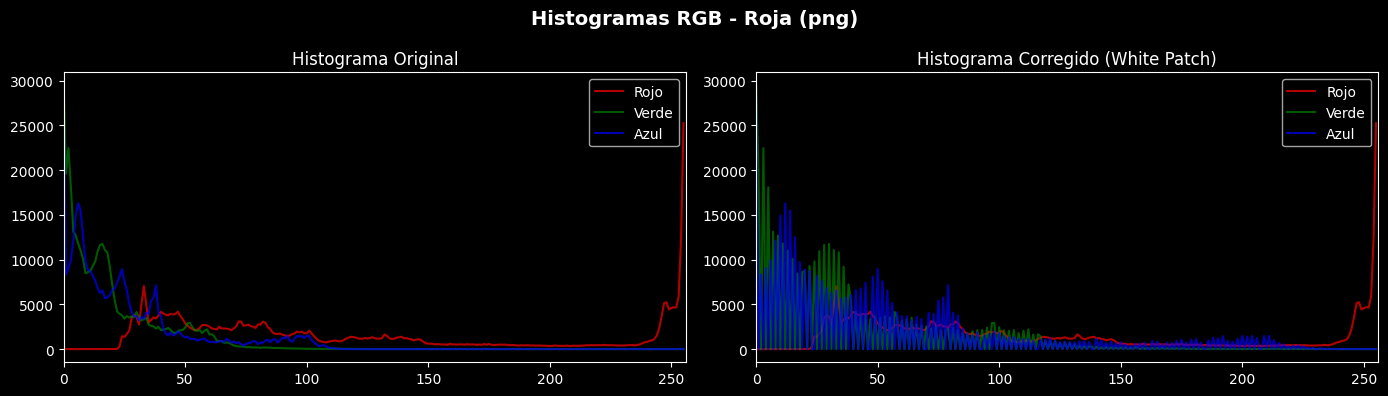

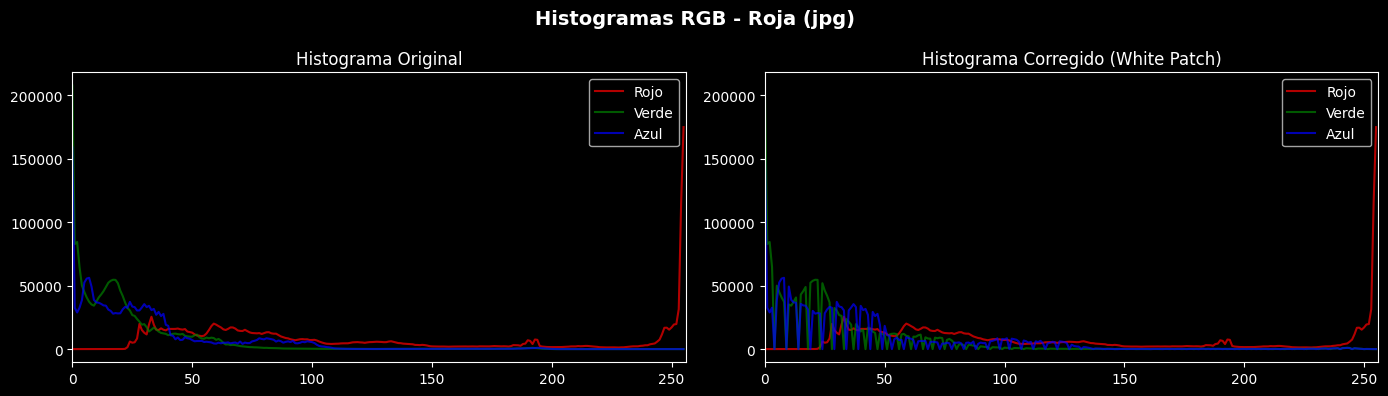

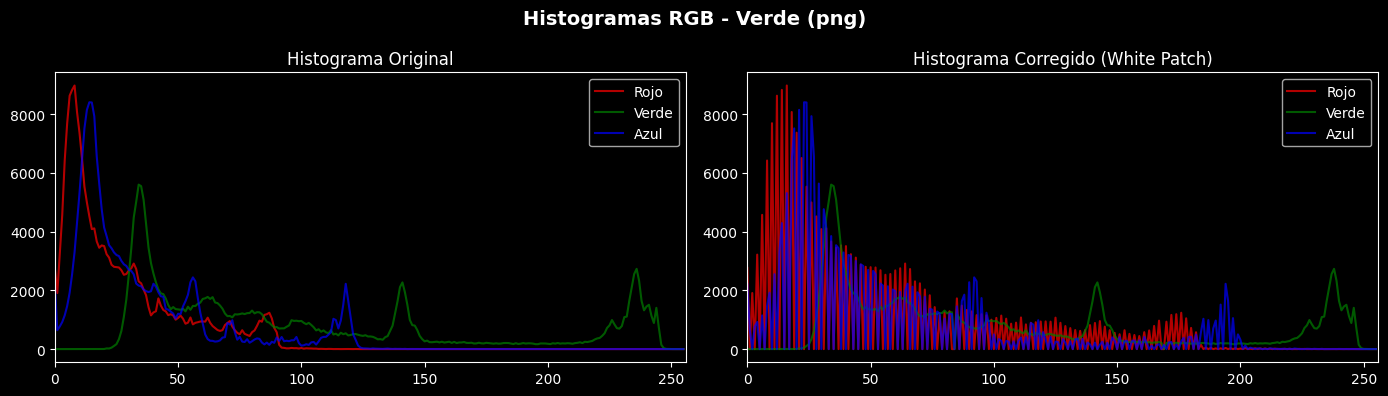

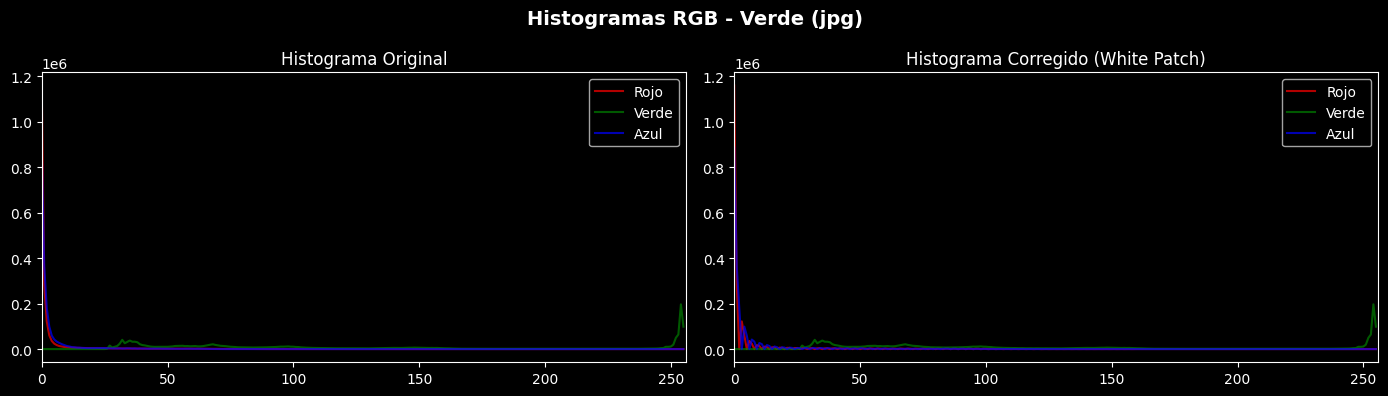

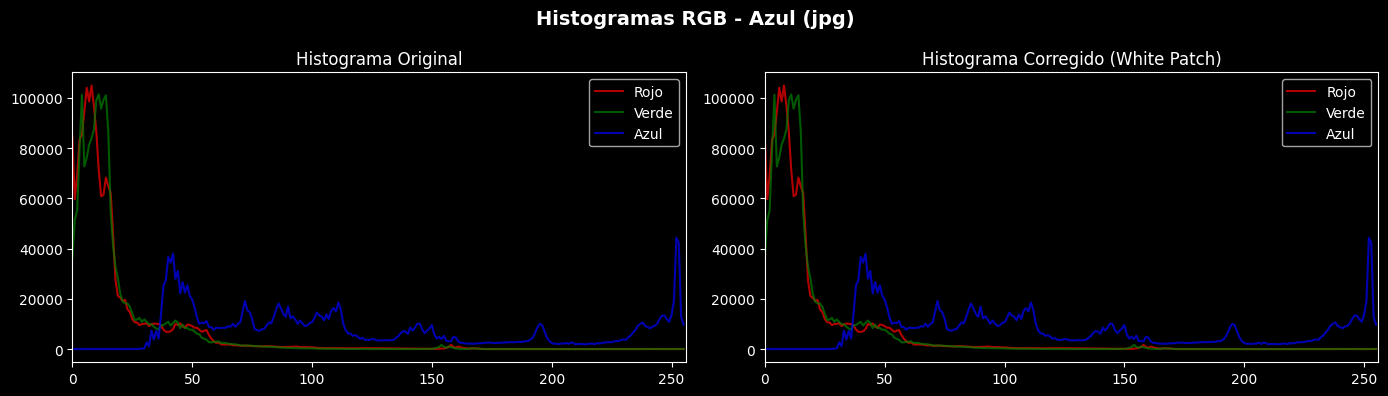

In [13]:
def plot_rgb_histograms(img_original, img_corrected, title):
    colors = ('r', 'g', 'b')
    labels = ('Rojo', 'Verde', 'Azul')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for i, (color, label) in enumerate(zip(colors, labels)):
        hist_orig = cv.calcHist([img_original], [i], None, [256], [0, 256])
        hist_corr = cv.calcHist([img_corrected], [i], None, [256], [0, 256])
        axes[0].plot(hist_orig, color=color, label=label, alpha=0.7)
        axes[1].plot(hist_corr, color=color, label=label, alpha=0.7)
    
    axes[0].set_title('Histograma Original')
    axes[0].legend()
    axes[0].set_xlim([0, 256])
    
    axes[1].set_title('Histograma Corregido de White Patch')
    axes[1].legend()
    axes[1].set_xlim([0, 256])
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Mostrar histogramas para cada imagen
for name, img in images.items():
    corrected = white_patch(img)
    plot_rgb_histograms(img, corrected, f'Histogramas RGB - {name}')

### Conclusion del algoritmo White Patch: posibles fallas

** REDACTAR CONCLUSIONES **


---
## Parte 2: Histogramas en escala de grises

### Cargamos imagenes en escala de grises y visualizarlas

img1_tp.png: shape=(288, 287), dtype=uint8, min=2, max=255
img2_tp.png: shape=(288, 287), dtype=uint8, min=2, max=255


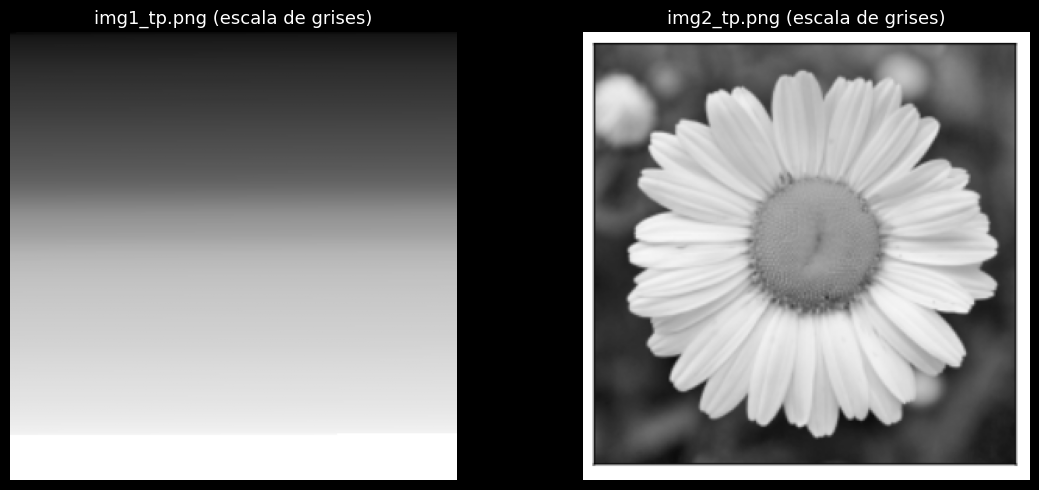

In [18]:
img1 = cv.imread('tp_1/material/img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('tp_1/material/img2_tp.png', cv.IMREAD_GRAYSCALE)

print(f'img1_tp.png: shape={img1.shape}, dtype={img1.dtype}, min={img1.min()}, max={img1.max()}')
print(f'img2_tp.png: shape={img2.shape}, dtype={img2.dtype}, min={img2.min()}, max={img2.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp.png (escala de grises)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp.png (escala de grises)', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Histogramas de las imágenes

Elegimos 64 bins, suficiente resolución para ver la distribución de intensidades sin el ruido que generaría usar 256 bins en imágenes pequeñas. También mostramos con 256 bins para comparación.

In [ ]:
n_bins = 64

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histograma img1 - 64 bins
axes[0, 0].hist(img1.ravel(), bins=n_bins, range=(0, 256), color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0, 0].set_title(f'Histograma img1_tp ({n_bins} bins)', fontsize=12)
axes[0, 0].set_xlabel('Intensidad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_xlim([0, 256])

# Histograma img2 - 64 bins
axes[0, 1].hist(img2.ravel(), bins=n_bins, range=(0, 256), color='coral', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0, 1].set_title(f'Histograma img2_tp ({n_bins} bins)', fontsize=12)
axes[0, 1].set_xlabel('Intensidad')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_xlim([0, 256])

# Histograma img1 - 256 bins
axes[1, 0].hist(img1.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
axes[1, 0].set_title(f'Histograma img1_tp (256 bins)', fontsize=12)
axes[1, 0].set_xlabel('Intensidad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_xlim([0, 256])

# Histograma img2 - 256 bins
axes[1, 1].hist(img2.ravel(), bins=256, range=(0, 256), color='coral', alpha=0.8)
axes[1, 1].set_title(f'Histograma img2_tp (256 bins)', fontsize=12)
axes[1, 1].set_xlabel('Intensidad')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Comparación superpuesta de histogramas

In [ ]:
# Superponemos ambos histogramas para comparación directa
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(img1.ravel(), bins=n_bins, range=(0, 256), color='steelblue', alpha=0.6,
        label='img1_tp (gradiente)', edgecolor='black', linewidth=0.3)
ax.hist(img2.ravel(), bins=n_bins, range=(0, 256), color='coral', alpha=0.6,
        label='img2_tp (flor)', edgecolor='black', linewidth=0.3)

ax.set_title('Comparación de histogramas (64 bins)', fontsize=14)
ax.set_xlabel('Intensidad', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.legend(fontsize=12)
ax.set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Histogramas normalizados

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(img1.ravel(), bins=n_bins, range=(0, 256), density=True, color='steelblue', alpha=0.6,
        label='img1_tp (gradiente)', edgecolor='black', linewidth=0.3)
ax.hist(img2.ravel(), bins=n_bins, range=(0, 256), density=True, color='coral', alpha=0.6,
        label='img2_tp (flor)', edgecolor='black', linewidth=0.3)

ax.set_title('Histogramas normalizados (densidad)', fontsize=14)
ax.set_xlabel('Intensidad', fontsize=12)
ax.set_ylabel('Densidad de probabilidad', fontsize=12)
ax.legend(fontsize=12)
ax.set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Estadisticas descriptivas

In [ ]:
print('Estadísticas de intensidad:')
print(f'  img1_tp -> Media: {img1.mean():.2f}, Std: {img1.std():.2f}, Mediana: {np.median(img1):.1f}')
print(f'  img2_tp -> Media: {img2.mean():.2f}, Std: {img2.std():.2f}, Mediana: {np.median(img2):.1f}')

### Conclusiones

** REDACTAR CONCLUSIONES **